In [1]:
import sys, os
import importlib
import torch.nn.functional as F
repo_start = f'../'
sys.path.append(repo_start)

from modules.utils.imports import *
from modules.binn_eql.model_wrapper_2d import model_wrapper
from modules.binn_eql.build_binn_eql_net import BINN
from modules.loaders.format_data import format_data_general
from modules.symbolic_net.visualize_surface import visualize_surface
from modules.generate_data.simulate_system import wave_pinning
from modules.symbolic_net.custom_norm import custom_norm
from modules.loaders.visualize_training_data import animate_data
from modules.utils.training_test_split import training_test_split

torch.set_printoptions(threshold=float('inf'))

In [2]:
# load params from configuration file
dir_name = '/work/users/s/m/smyersn/elston/projects/kinetics_binns/development/binn_eql_net/runs/diff_coeffs/1_first_attempt/du_0.01_dv_0.1/binn_eql_gls_1_pde_1_l05_0.01_repeat_8'
# dir_name = '/work/users/s/m/smyersn/elston/projects/kinetics_binns/development/binn_eql_net/runs/debugging/17_fine_tuning/binn_eql_gls_1_pde_1_l05_0.01_repeat_33'
config = {}
exec(Path(f'{dir_name}/config.cfg').read_text(encoding="utf8"), {}, config)

# Training data params
training_data_path = config['training_data_path']
species = int(config['species'])
dimensions = int(config['dimensions'])
epsilon = float(config['epsilon'])
points = int(config['points'])

# BINN params
diff_coeffs = [float(x) for x in config['diff_coeffs'].strip("()").split()]

# Symbolic Net params
duplicates = int(config['duplicates'])
degree = int(config['degree'])
gls_weight=float(config['gls_weight'])
pde_weight=float(config['pde_weight'])
l05_weight = float(config['l05_weight'])
l1_weight = float(config['l1_weight'])
param_bounds = float(config['param_bounds'])

In [3]:
training_data_path = '/work/users/s/m/smyersn/elston/projects/kinetics_binns/data/2d/wave_pinning/select/du_0.01_dv_0.1.npz'

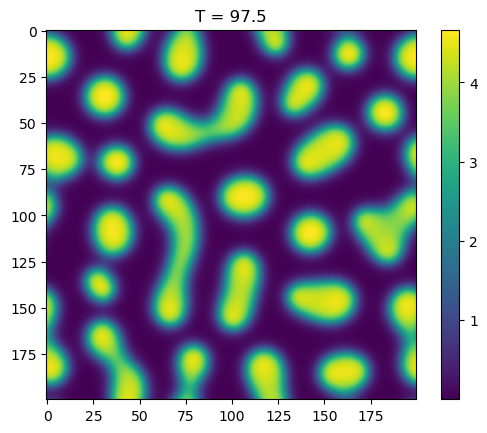

In [4]:
# Get GPU
device = 'cpu'

# Load training data (columns: x*dimensions, t, species concentrations)
training_data = format_data_general(dimensions, species, file=training_data_path)

# Add noise to training data if specified in config file
if epsilon != 0 or points != 0:
    training_data = noise_and_interpolate(training_data, points, epsilon, dimensions, species)

animate_data(training_data, dimensions, species, name=f'{dir_name}/training_data')

# Split training data
x_train, y_train, x_val, y_val = training_test_split(training_data, dimensions, device)

# initialize model and compile
binn = BINN(
    dimensions=dimensions,
    species=species, 
    duplicates=duplicates,
    data=x_train.cpu(), 
    diff_coeffs=diff_coeffs,
    degree=degree,
    gls_weight=gls_weight,
    pde_weight=pde_weight,
    l05_weight=l05_weight,
    l1_weight=l1_weight,
    param_bounds=param_bounds)

binn.to(device)

parameters = binn.parameters()

opt = torch.optim.Adam(parameters, lr=0.001)

model = model_wrapper(
    model=binn,
    optimizer=opt,
    loss=binn.loss,
    augmentation=None,
    save_name=f'{dir_name}/binn')

# model.load(f"{dir_name}/binn_best_val_fine_tuned_model", device=device)
model.load(f"{dir_name}/binn_best_val_model", device=device)

In [5]:
# Load training data (columns: x*dimensions, t, species concentrations)
xtuv = format_data_general(2, 2, file=training_data_path)

# Create mesh of u and v values sampled during training
u_triangle_mesh, v_triangle_mesh = lltriangle(xtuv[:, -2], xtuv[:, -1])
u, v = np.ravel(u_triangle_mesh), np.ravel(v_triangle_mesh)
training_data_nans = np.stack((u, v), axis=1)

# Remove nans from training data
mask = ~np.isnan(training_data_nans).any(axis=1)
training_data = training_data_nans[mask]

# INVESTIGATE LOSS

In [11]:
coeff = model.model.reaction.eql_layer.fc.weight
print(l05_weight * torch.norm(coeff, p=0.5))
print(l05_weight * custom_norm(coeff, 0.01))
print(model.model.reg_loss())

tensor(0.0028, grad_fn=<MulBackward0>)
tensor(0.0006, grad_fn=<MulBackward0>)
tensor(0.0006, grad_fn=<MeanBackward0>)


In [12]:
N = xtuv.shape[0]

# Generate 1000 random unique indices
indices = torch.randperm(N)[:10000]

data = torch.from_numpy(xtuv)[indices].float().requires_grad_()
pred_uv = model.model(data[:, :3]).requires_grad_()

true_pred = torch.cat([data[:, 3].unsqueeze(1), pred_uv[:, 0].unsqueeze(1), 
                          data[:, 4].unsqueeze(1), pred_uv[:, 1].unsqueeze(1)], 
                         dim=1)

In [13]:
print(torch.mean((true_pred[:, 0] - true_pred[:, 1])**2))
print(torch.mean((true_pred[:, 2] - true_pred[:, 3])**2))

tensor(0.0060, grad_fn=<MeanBackward0>)
tensor(0.0007, grad_fn=<MeanBackward0>)


In [25]:
true_pred

tensor([[7.3029e-01, 1.0566e+00, 8.6457e-01, 9.9072e-01],
        [9.5458e-04, 1.1417e+00, 3.2660e-01, 6.7616e-01],
        [2.2901e-01, 1.2315e+00, 3.9144e-01, 6.3592e-01],
        [6.1310e-01, 6.0662e-01, 3.1592e-01, 6.3551e-01],
        [4.7496e-03, 1.3519e-01, 3.3293e-01, 7.9275e-01],
        [2.5221e+00, 2.1982e+00, 3.0207e-01, 5.1315e-01],
        [5.2767e-02, 1.6245e-01, 3.2277e-01, 7.3138e-01],
        [5.2040e-01, 4.4867e+00, 3.1654e-01, 2.8777e-01],
        [1.0563e-02, 4.9810e-02, 3.2046e-01, 7.3536e-01],
        [3.0759e+00, 5.5350e-01, 3.5400e-01, 7.0846e-01],
        [2.4181e-03, 2.8972e+00, 3.5461e-01, 4.1684e-01],
        [4.6499e-02, 1.1198e+00, 3.2241e-01, 6.0151e-01],
        [1.6458e+00, 6.4798e-01, 3.1346e-01, 6.7442e-01],
        [2.8533e-01, 1.3122e+00, 3.2676e-01, 6.1018e-01],
        [9.5218e+00, 4.7119e-02, 2.2595e-01, 7.2741e-01],
        [2.8560e-01, 3.6086e+00, 3.2643e-01, 3.9337e-01],
        [1.4963e-04, 3.1312e+00, 3.2172e-01, 4.1100e-01],
        [8.451

In [14]:
model.model.loss(pred_uv, data[:, 3:])

Du, Dv: (tensor(1.7065e-09, grad_fn=<SelectBackward0>), tensor(0.0021, grad_fn=<SelectBackward0>))
xtuv: tensor([[3.1931e+00, 7.8380e+00, 5.7091e+01, 4.0089e+00, 3.3927e-01],
        [4.6902e+00, 5.7896e+00, 8.1360e+01, 3.7980e+00, 3.7274e-01],
        [3.6941e-01, 1.0917e+00, 6.4062e+01, 3.6504e-02, 7.4698e-01],
        [6.2908e+00, 8.9228e+00, 8.1907e+01, 1.4679e+00, 5.9059e-01],
        [3.1704e+00, 1.1482e+00, 3.8904e+01, 1.8192e-01, 7.2267e-01],
        [3.2613e+00, 2.0462e+00, 4.2462e+01, 3.5803e+00, 3.7988e-01],
        [1.6446e+00, 1.8157e-01, 8.0626e+01, 8.3555e-02, 7.1753e-01],
        [3.0412e+00, 3.9720e+00, 8.8896e+01, 3.3097e+00, 3.7597e-01],
        [6.1452e+00, 3.1929e+00, 9.6752e+01, 6.8742e-01, 6.1252e-01],
        [8.8170e+00, 3.6145e+00, 1.6973e+01, 3.3437e+00, 4.0561e-01],
        [4.6207e+00, 7.5788e+00, 5.5908e+01, 1.8962e-02, 7.3751e-01],
        [5.1939e+00, 7.0125e+00, 8.6793e+01, 3.8665e+00, 3.6305e-01],
        [2.8111e+00, 6.8328e+00, 8.2180e+00, 5.1567e-01

(tensor(0.0050, grad_fn=<AddBackward0>),
 tensor(0.0031, grad_fn=<MulBackward0>),
 tensor(0.0014, grad_fn=<AddBackward0>),
 tensor(0.0006, grad_fn=<AddBackward0>))

# INVESTIGATE SURFACES

In [ ]:
i = 3
u, v = training_data_nans[:, 0], training_data_nans[:, 1]
F_true = (-0.003 * (1 - u**3.788 / (1 + 0.00035 * u**3.788))).reshape(501, 501)

hill_start = model.model.reaction.eql_layer.num_poly_features
weights = model.model.reaction.eql_layer.fc.weight[0][hill_start:]
features = model.model.reaction.eql_layer.hill(torch.tensor(training_data_nans))
# weights = model.model.unpack_coeffs()[0]
# features = model.model.reaction.eql_layer.poly(torch.tensor(training_data_nans).float())

F_eql = (weights * features).cpu().detach().numpy()

visualize_surface(dir_name, u_triangle_mesh, v_triangle_mesh, F_true, F_eql[:, i].reshape(501, 501))

In [ ]:
params = 1, 1, 0.01
# F_true = wave_pinning(training_data_nans, params).reshape(501, 501)
F_true = (4.09326 * u + 
           -3.76719 * v + 
           -0.10483 * u * u + 
           -2.96473 * u**1.36452 / (1 + 1.04535 * u**1.36452) + 
           -6.01141 * v * u**0.97592 / (1 + 0.00446 * u**0.97592) + 
           5.83893 * (1 - v**1.31269 / (1 + 0.10954 * v**1.31269)) +
           -1.81741 * u * (1 - v**0.00024 / (1 + 2.18992 * v**0.00024))
          ).reshape(501, 501)

F_eql = model.model.reaction(torch.tensor(training_data_nans).float()).reshape(501, 501).detach().numpy()

visualize_surface(dir_name, u_triangle_mesh, v_triangle_mesh, F_true, F_eql)

In [ ]:
params = 1, 1, 0.01
F_true = wave_pinning(training_data_nans, params).reshape(501, 501)
F_eql = model.model.reaction(torch.tensor(training_data_nans).float()).reshape(501, 501).detach().numpy()

visualize_surface(dir_name, u_triangle_mesh, v_triangle_mesh, F_true, F_eql)